In [1]:
# Import des librairies principales pour l'analyse de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Désactiver les warnings pour un notebook plus lisible
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Chemin vers les données brutes (raw = données originales non modifiées)
DATA_PATH = "../data/raw/"

# Chargement du dataset d'entraînement (avec TARGET)
train = pd.read_csv(DATA_PATH + "application_train.csv")

# Chargement du dataset de test (sans TARGET)
test = pd.read_csv(DATA_PATH + "application_test.csv")

In [3]:
# Afficher le nombre de lignes et colonnes pour comprendre la taille des datasets
print("Train shape :", train.shape)
print("Test shape  :", test.shape)

Train shape : (307511, 122)
Test shape  : (48744, 121)


In [4]:
# Afficher les premières lignes pour comprendre la structure des variables
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Afficher les types de colonnes + valeurs manquantes potentielles
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
# TARGET = variable à prédire :
# 0 = client remboursé (bon client)
# 1 = client en défaut (mauvais client)

# Compter le nombre de chaque classe
train["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [7]:
# Afficher les proportions (très important pour voir le déséquilibre des classes)
train["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

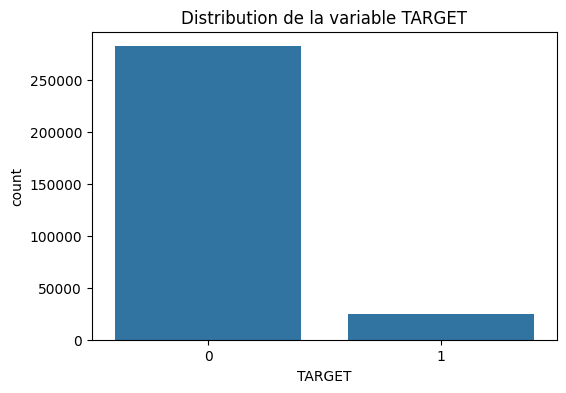

In [8]:
# Visualisation de la distribution de la TARGET
# Important pour comprendre le déséquilibre du problème de classification

plt.figure(figsize=(6,4))
sns.countplot(x="TARGET", data=train)

plt.title("Distribution de la variable TARGET")
plt.show()

In [9]:
# Calcul du pourcentage de valeurs manquantes par colonne

missing_percent = (
    train.isnull()
         .mean()
         .sort_values(ascending=False)
         * 100
)

# Afficher les 20 colonnes avec le plus de valeurs manquantes
missing_percent.head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

In [10]:
# Conserver uniquement les colonnes ayant au moins une valeur manquante

missing_df = missing_percent[missing_percent > 0]

print(f"Nombre de colonnes avec des valeurs manquantes : {len(missing_df)}")

missing_df.head(20)

Nombre de colonnes avec des valeurs manquantes : 67


COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

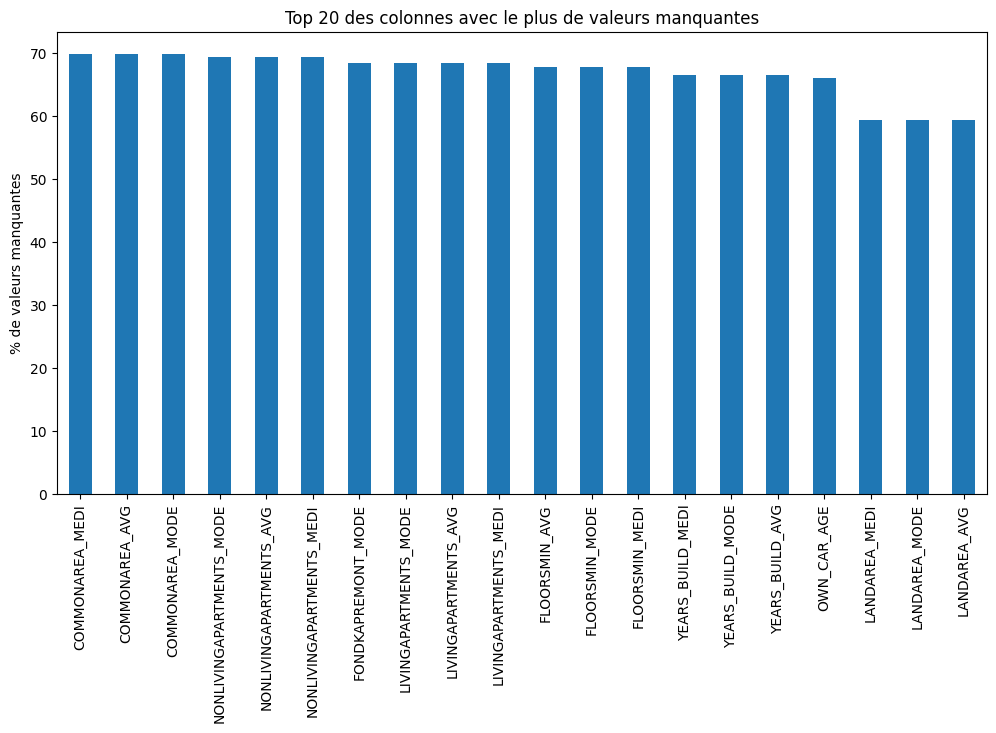

In [11]:
# Visualisation des colonnes avec le plus de valeurs manquantes

plt.figure(figsize=(12, 6))

missing_df.head(20).plot(kind="bar")

plt.title("Top 20 des colonnes avec le plus de valeurs manquantes")
plt.ylabel("% de valeurs manquantes")
plt.show()

In [12]:
# Nombre de lignes dupliquées

duplicates = train.duplicated().sum()

print(f"Nombre de doublons : {duplicates}")

Nombre de doublons : 0


In [13]:
# Vérifier qu'il y a bien un identifiant unique par client

train["SK_ID_CURR"].nunique()

print("Nombre de lignes :", len(train))
print("Nombre d'IDs uniques :", train["SK_ID_CURR"].nunique())

Nombre de lignes : 307511
Nombre d'IDs uniques : 307511


In [14]:
# Compter le nombre de colonnes par type

train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [15]:
# Liste des colonnes catégorielles

categorical_columns = train.select_dtypes(include=["object"]).columns

print(f"Nombre de variables catégorielles : {len(categorical_columns)}")
categorical_columns.tolist()

Nombre de variables catégorielles : 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [16]:
# Liste des colonnes numériques

numerical_columns = train.select_dtypes(include=["int64", "float64"]).columns

print(f"Nombre de variables numériques : {len(numerical_columns)}")

Nombre de variables numériques : 106


In [17]:
# Afficher quelques colonnes catégorielles

categorical_columns[:10]

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'],
      dtype='object')

In [18]:
# Répartition des valeurs de CODE_GENDER

train["CODE_GENDER"].value_counts()

# Répartition en pourcentage

train["CODE_GENDER"].value_counts(normalize=True)

CODE_GENDER
F      0.658344
M      0.341643
XNA    0.000013
Name: proportion, dtype: float64

In [19]:
# Pourcentage de valeurs manquantes par colonne

missing_percent = (
    train.isnull()
         .mean()
         .sort_values(ascending=False)
         * 100
)

# Affichage des 30 premières colonnes
missing_percent.head(30)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

In [20]:
# Colonnes avec plus de 50% de valeurs manquantes

high_missing = missing_percent[missing_percent > 50]

print(f"Nombre de colonnes avec plus de 50% de NaN : {len(high_missing)}")

high_missing

Nombre de colonnes avec plus de 50% de NaN : 41


COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

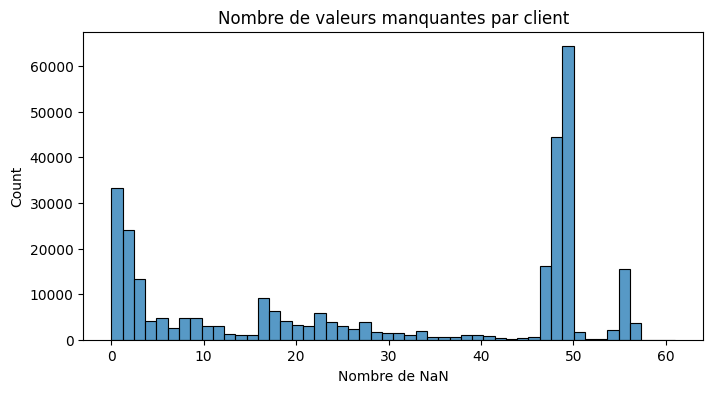

In [21]:
# Nombre de NaN par ligne

missing_per_row = train.isnull().sum(axis=1)

plt.figure(figsize=(8,4))
sns.histplot(missing_per_row, bins=50)

plt.title("Nombre de valeurs manquantes par client")
plt.xlabel("Nombre de NaN")
plt.show()

In [22]:
# Colonnes sans aucune valeur manquante

no_missing = missing_percent[missing_percent == 0]

print(f"Colonnes sans NaN : {len(no_missing)}")

Colonnes sans NaN : 55


In [23]:
# Résumé statistique des variables numériques

train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


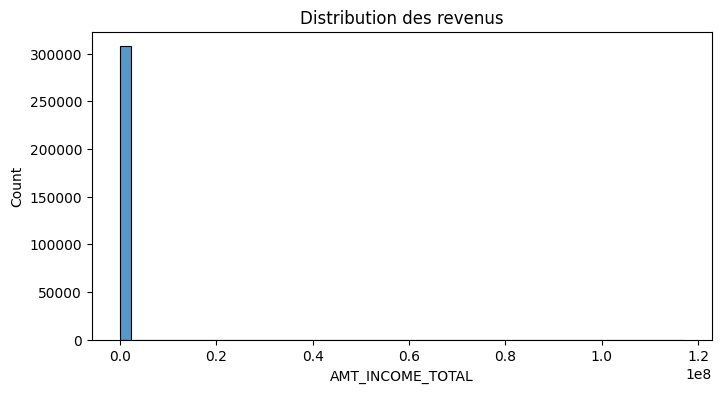

In [24]:
# Distribution du revenu annuel

plt.figure(figsize=(8,4))

sns.histplot(
    train["AMT_INCOME_TOTAL"],
    bins=50
)

plt.title("Distribution des revenus")
plt.show()

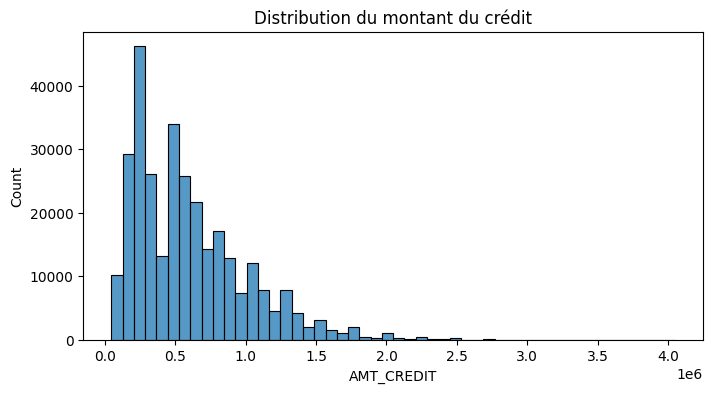

In [25]:
# Distribution du montant demandé

plt.figure(figsize=(8,4))

sns.histplot(
    train["AMT_CREDIT"],
    bins=50
)

plt.title("Distribution du montant du crédit")
plt.show()

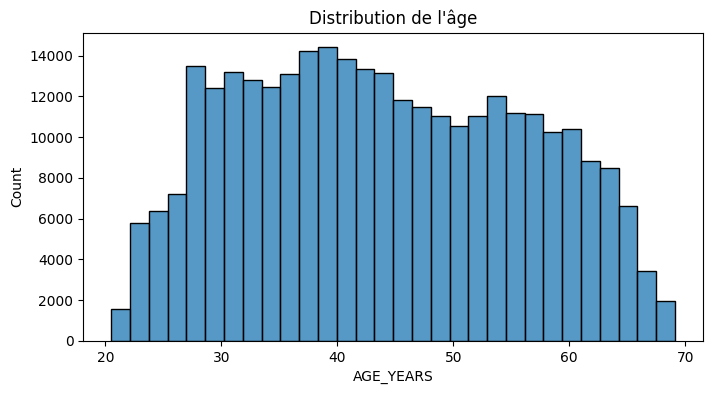

In [26]:
# Conversion en âge positif

train["AGE_YEARS"] = (
    -train["DAYS_BIRTH"] / 365
)

# Distribution de l'âge

plt.figure(figsize=(8,4))

sns.histplot(
    train["AGE_YEARS"],
    bins=30
)

plt.title("Distribution de l'âge")
plt.show()

In [27]:
# =========================
# FEATURE ENGINEERING SIMPLE
# =========================

# 1. Proportion du temps travaillé par rapport à l'âge du client
train["DAYS_EMPLOYED_PERC"] = train["DAYS_EMPLOYED"] / train["DAYS_BIRTH"]

# 2. Capacité de remboursement (revenu vs crédit)
train["INCOME_CREDIT_PERC"] = train["AMT_INCOME_TOTAL"] / train["AMT_CREDIT"]

# 3. Revenu par membre du foyer
train["INCOME_PER_PERSON"] = train["AMT_INCOME_TOTAL"] / train["CNT_FAM_MEMBERS"]

# 4. Effort financier mensuel (annuité / revenu)
train["ANNUITY_INCOME_PERC"] = train["AMT_ANNUITY"] / train["AMT_INCOME_TOTAL"]

# 5. Taux de remboursement du crédit
train["PAYMENT_RATE"] = train["AMT_ANNUITY"] / train["AMT_CREDIT"]

In [28]:
# Remplacer les valeurs infinies créées par les divisions

train.replace([np.inf, -np.inf], np.nan, inplace=True)

In [29]:
# Vérifier les nouvelles features créées

train[[
    "DAYS_EMPLOYED_PERC",
    "INCOME_CREDIT_PERC",
    "INCOME_PER_PERSON",
    "ANNUITY_INCOME_PERC",
    "PAYMENT_RATE"
]].head()

,DAYS_EMPLOYED_PERC,INCOME_CREDIT_PERC,INCOME_PER_PERSON,ANNUITY_INCOME_PERC,PAYMENT_RATE
0,0.067329,0.498036,202500.0,0.121978,0.060749
1,0.070862,0.208736,135000.0,0.132217,0.027598
2,0.011814,0.500000,67500.0,0.100000,0.050000
3,0.159905,0.431748,67500.0,0.219900,0.094941
4,0.152418,0.236842,121500.0,0.179963,0.042623


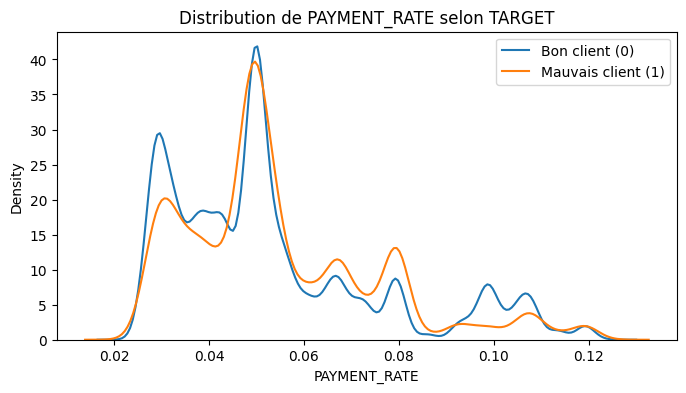

In [30]:
# Comparer PAYMENT_RATE entre bons et mauvais clients

plt.figure(figsize=(8,4))

sns.kdeplot(
    train[train["TARGET"] == 0]["PAYMENT_RATE"],
    label="Bon client (0)"
)

sns.kdeplot(
    train[train["TARGET"] == 1]["PAYMENT_RATE"],
    label="Mauvais client (1)"
)

plt.legend()
plt.title("Distribution de PAYMENT_RATE selon TARGET")
plt.show()

# Exploration de bureau.csv

In [31]:
# Chargement des données bureau

bureau = pd.read_csv("../data/raw/bureau.csv")

print("Shape :", bureau.shape)

bureau.head()

Shape : (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [32]:
# Informations générales

bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [33]:
# Nombre de clients uniques

print("Clients uniques :", bureau["SK_ID_CURR"].nunique())

print("Lignes totales :", len(bureau))

Clients uniques : 305811
Lignes totales : 1716428


In [34]:
# Nombre de clients uniques

# Nombre de crédits externes par client

credits_per_client = (
    bureau.groupby("SK_ID_CURR")
          .size()
)

print(credits_per_client.describe())

count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
dtype: float64


In [35]:
# Etat des crédits
bureau["CREDIT_ACTIVE"].value_counts(normalize=True)

CREDIT_ACTIVE
Closed      0.628790
Active      0.367395
Sold        0.003803
Bad debt    0.000012
Name: proportion, dtype: float64

In [36]:
# =========================
# BUREAU BALANCE DATASET
# =========================

bureau_balance = pd.read_csv("../data/raw/bureau_balance.csv")

print("Shape :", bureau_balance.shape)

bureau_balance.head()

Shape : (27299925, 3)


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [37]:
# Informations générales

bureau_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


In [38]:
# Répartition des statuts

bureau_balance["STATUS"].value_counts()

STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64

In [39]:
# One-hot encoding du STATUS

bureau_balance = pd.get_dummies(bureau_balance, columns=["STATUS"])

In [40]:
# Agrégation par SK_ID_BUREAU

bb_agg = bureau_balance.groupby("SK_ID_BUREAU").agg(["mean", "sum", "size"])

bb_agg.columns = pd.Index([
    "BB_" + e[0] + "_" + e[1].upper()
    for e in bb_agg.columns
])

bb_agg.head()

,BB_MONTHS_BALANCE_MEAN,BB_MONTHS_BALANCE_SUM,BB_MONTHS_BALANCE_SIZE,BB_STATUS_0_MEAN,BB_STATUS_0_SUM,BB_STATUS_0_SIZE,BB_STATUS_1_MEAN,BB_STATUS_1_SUM,BB_STATUS_1_SIZE,BB_STATUS_2_MEAN,...,BB_STATUS_4_SIZE,BB_STATUS_5_MEAN,BB_STATUS_5_SUM,BB_STATUS_5_SIZE,BB_STATUS_C_MEAN,BB_STATUS_C_SUM,BB_STATUS_C_SIZE,BB_STATUS_X_MEAN,BB_STATUS_X_SUM,BB_STATUS_X_SIZE
SK_ID_BUREAU,,,,,,,,,,,,,,,,,,,,,
5001709,-48.0,-4656,97,0.000000,0,97,0.0,0,97,0.0,...,97,0.0,0,97,0.886598,86,97,0.113402,11,97
5001710,-41.0,-3403,83,0.060241,5,83,0.0,0,83,0.0,...,83,0.0,0,83,0.578313,48,83,0.361446,30,83
5001711,-1.5,-6,4,0.750000,3,4,0.0,0,4,0.0,...,4,0.0,0,4,0.000000,0,4,0.250000,1,4
5001712,-9.0,-171,19,0.526316,10,19,0.0,0,19,0.0,...,19,0.0,0,19,0.473684,9,19,0.000000,0,19
5001713,-10.5,-231,22,0.000000,0,22,0.0,0,22,0.0,...,22,0.0,0,22,0.000000,0,22,1.000000,22,22


In [41]:
bureau = bureau.join(bb_agg, on="SK_ID_BUREAU")

In [42]:
# Afficher les colonnes de bureau_balance
print(bureau_balance.columns.tolist())

['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS_0', 'STATUS_1', 'STATUS_2', 'STATUS_3', 'STATUS_4', 'STATUS_5', 'STATUS_C', 'STATUS_X']


In [43]:
# Définition des agrégations pour bureau_balance

bb_aggregations = {
    "MONTHS_BALANCE": ["min", "max", "size"]
}

# Pour chaque statut encodé,
# calculer sa fréquence moyenne
for col in bureau_balance.columns:
    if col.startswith("STATUS_"):
        bb_aggregations[col] = ["mean"]

bb_aggregations

{'MONTHS_BALANCE': ['min', 'max', 'size'],
 'STATUS_0': ['mean'],
 'STATUS_1': ['mean'],
 'STATUS_2': ['mean'],
 'STATUS_3': ['mean'],
 'STATUS_4': ['mean'],
 'STATUS_5': ['mean'],
 'STATUS_C': ['mean'],
 'STATUS_X': ['mean']}

In [44]:
# Agrégation par crédit (SK_ID_BUREAU)

bb_agg = (
    bureau_balance
    .groupby("SK_ID_BUREAU")
    .agg(bb_aggregations)
)

# Renommer les colonnes
bb_agg.columns = pd.Index([
    f"{col}_{stat.upper()}"
    for col, stat in bb_agg.columns
])

bb_agg.head()

,MONTHS_BALANCE_MIN,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN
SK_ID_BUREAU,,,,,,,,,,,
5001709,-96,0,97,0.000000,0.0,0.0,0.0,0.0,0.0,0.886598,0.113402
5001710,-82,0,83,0.060241,0.0,0.0,0.0,0.0,0.0,0.578313,0.361446
5001711,-3,0,4,0.750000,0.0,0.0,0.0,0.0,0.0,0.000000,0.250000
5001712,-18,0,19,0.526316,0.0,0.0,0.0,0.0,0.0,0.473684,0.000000
5001713,-21,0,22,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.000000


In [45]:
# Fusion bureau + bureau_balance agrégé

bureau = bureau.join(
    bb_agg,
    how="left",
    on="SK_ID_BUREAU"
)

print(bureau.shape)
bureau.head()

(1716428, 55)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,...,MONTHS_BALANCE_MAX,MONTHS_BALANCE_SIZE,STATUS_0_MEAN,STATUS_1_MEAN,STATUS_2_MEAN,STATUS_3_MEAN,STATUS_4_MEAN,STATUS_5_MEAN,STATUS_C_MEAN,STATUS_X_MEAN
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# Agrégation de bureau au niveau client

bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "DAYS_CREDIT": ["min", "max", "mean"],
    "CREDIT_DAY_OVERDUE": ["max", "mean"],
    "AMT_CREDIT_SUM": ["sum", "mean"],
    "AMT_CREDIT_SUM_DEBT": ["sum", "mean"],
    "AMT_CREDIT_SUM_OVERDUE": ["max", "mean"],
    "CNT_CREDIT_PROLONG": ["sum"],

    # BONUS : historique déjà agrégé (ok ici car déjà résumé par crédit)
    "STATUS_0_MEAN": ["mean"],
    "STATUS_1_MEAN": ["mean"],
})

In [47]:
bureau_agg.columns = pd.Index([
    "BURO_" + "_".join(col).upper()
    for col in bureau_agg.columns
])

bureau_agg.head()

,BURO_DAYS_CREDIT_MIN,BURO_DAYS_CREDIT_MAX,BURO_DAYS_CREDIT_MEAN,BURO_CREDIT_DAY_OVERDUE_MAX,BURO_CREDIT_DAY_OVERDUE_MEAN,BURO_AMT_CREDIT_SUM_SUM,BURO_AMT_CREDIT_SUM_MEAN,BURO_AMT_CREDIT_SUM_DEBT_SUM,BURO_AMT_CREDIT_SUM_DEBT_MEAN,BURO_AMT_CREDIT_SUM_OVERDUE_MAX,BURO_AMT_CREDIT_SUM_OVERDUE_MEAN,BURO_CNT_CREDIT_PROLONG_SUM,BURO_STATUS_0_MEAN_MEAN,BURO_STATUS_1_MEAN_MEAN
SK_ID_CURR,,,,,,,,,,,,,,
100001,-1572,-49,-735.000000,0,0.0,1453365.000,207623.571429,596686.5,85240.928571,0.0,0.0,0,0.336651,0.007519
100002,-1437,-103,-874.000000,0,0.0,865055.565,108131.945625,245781.0,49156.200000,0.0,0.0,0,0.406960,0.255682
100003,-2586,-606,-1400.750000,0,0.0,1017400.500,254350.125000,0.0,0.000000,0.0,0.0,0,NaN,NaN
100004,-1326,-408,-867.000000,0,0.0,189037.800,94518.900000,0.0,0.000000,0.0,0.0,0,NaN,NaN
100005,-373,-62,-190.666667,0,0.0,657126.000,219042.000000,568408.5,189469.500000,0.0,0.0,0,0.735043,0.000000


In [48]:
df = pd.concat([train, test], axis=0, ignore_index=True)
df.shape

(356255, 128)

In [49]:
df = df.join(bureau_agg, on="SK_ID_CURR", how="left")
print(df.shape)

(356255, 142)


#Previous_application.csv

In [50]:
prev = pd.read_csv(DATA_PATH + "previous_application.csv")

print(prev.shape)
prev.head()

(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
prev = pd.read_csv(DATA_PATH + "previous_application.csv")

print(prev.shape)
prev.head()

(1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Analyse des valeurs manquantes
prev.isna().mean().sort_values(ascending=False).head(10)

RATE_INTEREST_PRIVILEGED     0.996437
RATE_INTEREST_PRIMARY        0.996437
AMT_DOWN_PAYMENT             0.536365
RATE_DOWN_PAYMENT            0.536365
NAME_TYPE_SUITE              0.491198
NFLAG_INSURED_ON_APPROVAL    0.402981
DAYS_TERMINATION             0.402981
DAYS_LAST_DUE                0.402981
DAYS_LAST_DUE_1ST_VERSION    0.402981
DAYS_FIRST_DUE               0.402981
dtype: float64

In [53]:
# Analyse du statut des anciennes demandes de crédit
# Permet de voir si les demandes ont été acceptées, refusées, annulées, etc.

prev["NAME_CONTRACT_STATUS"].value_counts(normalize=True)

NAME_CONTRACT_STATUS
Approved        0.620747
Canceled        0.189388
Refused         0.174036
Unused offer    0.015828
Name: proportion, dtype: float64

In [54]:
# Comparaison entre le montant demandé et le montant réellement accordé
# Permet de voir si la banque réduit souvent les crédits

prev[["AMT_APPLICATION", "AMT_CREDIT"]].describe()

,AMT_APPLICATION,AMT_CREDIT
count,1.670214e+06,1.670213e+06
mean,1.752339e+05,1.961140e+05
std,2.927798e+05,3.185746e+05
min,0.000000e+00,0.000000e+00
25%,1.872000e+04,2.416050e+04
50%,7.104600e+04,8.054100e+04
75%,1.803600e+05,2.164185e+05
max,6.905160e+06,6.905160e+06


In [55]:
# Analyse du moment où les décisions de crédit ont été prises
# (valeurs négatives = jours avant la demande actuelle)

prev["DAYS_DECISION"].describe()

count    1.670214e+06
mean    -8.806797e+02
std      7.790997e+02
min     -2.922000e+03
25%     -1.300000e+03
50%     -5.810000e+02
75%     -2.800000e+02
max     -1.000000e+00
Name: DAYS_DECISION, dtype: float64

In [56]:
prev[["AMT_APPLICATION", "AMT_CREDIT"]].describe()

,AMT_APPLICATION,AMT_CREDIT
count,1.670214e+06,1.670213e+06
mean,1.752339e+05,1.961140e+05
std,2.927798e+05,3.185746e+05
min,0.000000e+00,0.000000e+00
25%,1.872000e+04,2.416050e+04
50%,7.104600e+04,8.054100e+04
75%,1.803600e+05,2.164185e+05
max,6.905160e+06,6.905160e+06


In [57]:
prev["DAYS_DECISION"].describe()

count    1.670214e+06
mean    -8.806797e+02
std      7.790997e+02
min     -2.922000e+03
25%     -1.300000e+03
50%     -5.810000e+02
75%     -2.800000e+02
max     -1.000000e+00
Name: DAYS_DECISION, dtype: float64

In [58]:
mean_days = prev.groupby("SK_ID_CURR")["DAYS_DECISION"].mean()

In [59]:
last_request = prev.groupby("SK_ID_CURR")["DAYS_DECISION"].max()

In [60]:
first_request = prev.groupby("SK_ID_CURR")["DAYS_DECISION"].min()


In [61]:
first_request = prev.groupby("SK_ID_CURR")["DAYS_DECISION"].min()

In [62]:
# Feature engineering sur previous_application
# Objectif : résumer le comportement des clients sur leurs anciennes demandes de crédit

prev_agg = prev.groupby("SK_ID_CURR").agg({

    # 💰 Montants demandés et accordés
    # Permet de voir les habitudes financières du client
    "AMT_APPLICATION": ["mean", "max"],
    "AMT_CREDIT": ["mean", "max"],
    "AMT_ANNUITY": ["mean", "sum"],

    # ⏳ Temporalité des demandes
    # Permet de comprendre l'ancienneté et la fréquence des demandes
    "DAYS_DECISION": ["min", "max", "mean"],

    # 📆 Durée des crédits demandés
    # Permet de voir le type de financement choisi par le client
    "CNT_PAYMENT": ["mean"]
})

In [63]:
# Renommage des colonnes pour rendre les features exploitables par le modèle
# On ajoute le préfixe PREV_ pour identifier la source des variables

prev_agg.columns = pd.Index([
    "PREV_" + "_".join(col).upper()
    for col in prev_agg.columns
])

# Vérification rapide du résultat
prev_agg.head()

,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_SUM,PREV_DAYS_DECISION_MIN,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MEAN,PREV_CNT_PAYMENT_MEAN
SK_ID_CURR,,,,,,,,,,
100001,24835.50,24835.5,23787.00,23787.0,3951.000,3951.000,-1740,-1740,-1740.0,8.0
100002,179055.00,179055.0,179055.00,179055.0,9251.775,9251.775,-606,-606,-606.0,24.0
100003,435436.50,900000.0,484191.00,1035882.0,56553.990,169661.970,-2341,-746,-1305.0,10.0
100004,24282.00,24282.0,20106.00,20106.0,5357.250,5357.250,-815,-815,-815.0,4.0
100005,22308.75,44617.5,20076.75,40153.5,4813.200,4813.200,-757,-315,-536.0,12.0


In [64]:
prev_agg.shape

(338857, 10)

In [65]:
# Fusion des features previous_application dans le dataset principal
# On enrichit les données clients avec leur historique de demandes de crédit internes

df = df.join(prev_agg, on="SK_ID_CURR", how="left")

# Vérification de la nouvelle dimension du dataset
print("Shape après fusion previous_application :", df.shape)

# Aperçu rapide du dataset enrichi
df.head()

Shape après fusion previous_application : (356255, 152)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_MAX,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_SUM,PREV_DAYS_DECISION_MIN,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MEAN,PREV_CNT_PAYMENT_MEAN
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,179055.00,179055.0,179055.00,179055.0,9251.775,9251.775,-606.0,-606.0,-606.000000,24.000000
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,435436.50,900000.0,484191.00,1035882.0,56553.990,169661.970,-2341.0,-746.0,-1305.000000,10.000000
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,24282.00,24282.0,20106.00,20106.0,5357.250,5357.250,-815.0,-815.0,-815.000000,4.000000
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,272203.26,688500.0,291695.50,906615.0,23651.175,141907.050,-617.0,-181.0,-272.444444,23.000000
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,150530.25,247500.0,166638.75,284400.0,12278.805,73672.830,-2357.0,-374.0,-1222.833333,20.666667


In [66]:
# Chargement du fichier POS_CASH_balance
# Il contient le suivi mensuel des crédits en cours

pos = pd.read_csv(DATA_PATH + "POS_CASH_balance.csv")

# Vérification de la taille du dataset
print("Shape POS_CASH_balance :", pos.shape)

# Aperçu des données
pos.head()

Shape POS_CASH_balance : (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


In [67]:
# Analyse rapide des valeurs manquantes
pos.isna().mean().sort_values(ascending=False).head(10)

CNT_INSTALMENT_FUTURE    0.002608
CNT_INSTALMENT           0.002607
SK_ID_PREV               0.000000
SK_ID_CURR               0.000000
MONTHS_BALANCE           0.000000
NAME_CONTRACT_STATUS     0.000000
SK_DPD                   0.000000
SK_DPD_DEF               0.000000
dtype: float64

In [68]:
# Agrégation des données POS_CASH au niveau client
# Objectif : résumer le comportement de remboursement mensuel

pos_agg = pos.groupby("SK_ID_CURR").agg({

    # 📆 ancienneté du suivi
    "MONTHS_BALANCE": ["min", "max", "mean"],

    # 📊 comportement de paiement
    "CNT_INSTALMENT": ["mean", "max"],
    "CNT_INSTALMENT_FUTURE": ["mean", "max"]
})

In [69]:
# Renommage pour rendre les features exploitables par LightGBM
# Préfixe POS_ pour identifier la source

pos_agg.columns = pd.Index([
    "POS_" + "_".join(col).upper()
    for col in pos_agg.columns
])

# Aperçu des features créées
pos_agg.head()

,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX
SK_ID_CURR,,,,,,,
100001,-96,-53,-72.555556,4.000000,4.0,1.444444,4.0
100002,-19,-1,-10.000000,24.000000,24.0,15.000000,24.0
100003,-77,-18,-43.785714,10.107143,12.0,5.785714,12.0
100004,-27,-24,-25.500000,3.750000,4.0,2.250000,4.0
100005,-25,-15,-20.000000,11.700000,12.0,7.200000,12.0


In [70]:
# Fusion des features POS_CASH_balance dans le dataset principal
# On enrichit les données clients avec leur comportement de remboursement mensuel

df = df.join(pos_agg, on="SK_ID_CURR", how="left")

# Vérification de la nouvelle dimension du dataset
print("Shape après fusion POS_CASH :", df.shape)

# Aperçu rapide
df.head()

Shape après fusion POS_CASH : (356255, 159)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MEAN,PREV_CNT_PAYMENT_MEAN,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MEAN,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-606.0,-606.000000,24.000000,-19.0,-1.0,-10.000000,24.000000,24.0,15.000000,24.0
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-746.0,-1305.000000,10.000000,-77.0,-18.0,-43.785714,10.107143,12.0,5.785714,12.0
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-815.0,-815.000000,4.000000,-27.0,-24.0,-25.500000,3.750000,4.0,2.250000,4.0
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,-181.0,-272.444444,23.000000,-20.0,-1.0,-9.619048,12.000000,48.0,8.650000,48.0
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-374.0,-1222.833333,20.666667,-77.0,-1.0,-33.636364,15.333333,24.0,8.969697,24.0


In [71]:
# Chargement des données de carte de crédit
# Chaque ligne représente un mois de suivi d'une carte bancaire client

cc = pd.read_csv(DATA_PATH + "credit_card_balance.csv")

# Vérification de la taille du dataset
print("Shape credit_card_balance :", cc.shape)

# Aperçu des données
cc.head()

Shape credit_card_balance : (3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [72]:
# Analyse du taux de valeurs manquantes
# Permet d'identifier les variables exploitables

cc.isna().mean().sort_values(ascending=False).head(10)

AMT_PAYMENT_CURRENT           0.199981
AMT_DRAWINGS_ATM_CURRENT      0.195249
CNT_DRAWINGS_POS_CURRENT      0.195249
AMT_DRAWINGS_OTHER_CURRENT    0.195249
AMT_DRAWINGS_POS_CURRENT      0.195249
CNT_DRAWINGS_OTHER_CURRENT    0.195249
CNT_DRAWINGS_ATM_CURRENT      0.195249
CNT_INSTALMENT_MATURE_CUM     0.079482
AMT_INST_MIN_REGULARITY       0.079482
SK_ID_PREV                    0.000000
dtype: float64

In [73]:
# Agrégation des données de carte bancaire par client
# Objectif : résumer le comportement financier mensuel

cc_agg = cc.groupby("SK_ID_CURR").agg({

    # 📆 ancienneté du suivi
    "MONTHS_BALANCE": ["min", "max", "mean"],

    # 💳 utilisation du crédit
    "AMT_BALANCE": ["mean", "max"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean", "max"],

    # 💸 comportement de paiement
    "AMT_PAYMENT_TOTAL_CURRENT": ["mean", "sum"],
    "AMT_DRAWINGS_ATM_CURRENT": ["mean", "sum"]
})

In [74]:
# Renommage pour rendre les features exploitables par LightGBM
# Préfixe CC_ pour identifier la source carte bancaire

cc_agg.columns = pd.Index([
    "CC_" + "_".join(col).upper()
    for col in cc_agg.columns
])

# Aperçu des features créées
cc_agg.head()

,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_MEAN,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_SUM
SK_ID_CURR,,,,,,,,,,,
100006,-6,-1,-3.5,0.000000,0.00,270000.000000,270000,0.000000,0.000,NaN,0.0
100011,-75,-2,-38.5,54482.111149,189000.00,164189.189189,180000,4520.067568,334485.000,2432.432432,180000.0
100013,-96,-1,-48.5,18159.919219,161420.22,131718.750000,157500,6817.172344,654448.545,6350.000000,571500.0
100021,-18,-2,-10.0,0.000000,0.00,675000.000000,675000,0.000000,0.000,NaN,0.0
100023,-11,-4,-7.5,0.000000,0.00,135000.000000,225000,0.000000,0.000,NaN,0.0


In [75]:
# Fusion des features credit_card_balance dans le dataset principal
# On enrichit les clients avec leur comportement de carte bancaire

df = df.join(cc_agg, on="SK_ID_CURR", how="left")

# Vérification
print("Shape après fusion credit_card_balance :", df.shape)

df.head()

Shape après fusion credit_card_balance : (356255, 170)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_MEAN,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_SUM
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,-1.0,-3.5,0.0,0.0,270000.0,270000.0,0.0,0.0,NaN,0.0
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
# Chargement des paiements d'installments
# Chaque ligne représente un remboursement effectué par un client

inst = pd.read_csv(DATA_PATH + "installments_payments.csv")

# Vérification de la taille du dataset
print("Shape installments_payments :", inst.shape)

# Aperçu des données
inst.head()

Shape installments_payments : (13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [77]:
# Analyse des valeurs manquantes
inst.isna().mean().sort_values(ascending=False).head(10)

DAYS_ENTRY_PAYMENT        0.000214
AMT_PAYMENT               0.000214
SK_ID_PREV                0.000000
SK_ID_CURR                0.000000
NUM_INSTALMENT_VERSION    0.000000
NUM_INSTALMENT_NUMBER     0.000000
DAYS_INSTALMENT           0.000000
AMT_INSTALMENT            0.000000
dtype: float64

In [78]:
# Feature engineering sur installments_payments
# Objectif : capturer le comportement réel de remboursement

inst_agg = inst.groupby("SK_ID_CURR").agg({

    # 📆 ancienneté des paiements
    "DAYS_INSTALMENT": ["min", "max", "mean"],
    "DAYS_ENTRY_PAYMENT": ["min", "max", "mean"],

    # 💸 montants
    "AMT_INSTALMENT": ["mean", "sum"],
    "AMT_PAYMENT": ["mean", "sum"]
})

In [79]:
# Renommage pour LightGBM
# Préfixe INST_ pour identifier installments

inst_agg.columns = pd.Index([
    "INST_" + "_".join(col).upper()
    for col in inst_agg.columns
])

# Aperçu des features générées
inst_agg.head()

,INST_DAYS_INSTALMENT_MIN,INST_DAYS_INSTALMENT_MAX,INST_DAYS_INSTALMENT_MEAN,INST_DAYS_ENTRY_PAYMENT_MIN,INST_DAYS_ENTRY_PAYMENT_MAX,INST_DAYS_ENTRY_PAYMENT_MEAN,INST_AMT_INSTALMENT_MEAN,INST_AMT_INSTALMENT_SUM,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM
SK_ID_CURR,,,,,,,,,,
100001,-2916.0,-1619.0,-2187.714286,-2916.0,-1628.0,-2195.000000,5885.132143,41195.925,5885.132143,41195.925
100002,-565.0,-25.0,-295.000000,-587.0,-49.0,-315.421053,11559.247105,219625.695,11559.247105,219625.695
100003,-2310.0,-536.0,-1378.160000,-2324.0,-544.0,-1385.320000,64754.586000,1618864.650,64754.586000,1618864.650
100004,-784.0,-724.0,-754.000000,-795.0,-727.0,-761.666667,7096.155000,21288.465,7096.155000,21288.465
100005,-706.0,-466.0,-586.000000,-736.0,-470.0,-609.555556,6240.205000,56161.845,6240.205000,56161.845


In [80]:
# Fusion des features installments_payments dans le dataset principal
# On enrichit les clients avec leur comportement réel de remboursement

df = df.join(inst_agg, on="SK_ID_CURR", how="left")

# Vérification de la nouvelle dimension du dataset
print("Shape après fusion installments_payments :", df.shape)

# Aperçu du dataset enrichi
df.head()

Shape après fusion installments_payments : (356255, 180)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_DAYS_INSTALMENT_MIN,INST_DAYS_INSTALMENT_MAX,INST_DAYS_INSTALMENT_MEAN,INST_DAYS_ENTRY_PAYMENT_MIN,INST_DAYS_ENTRY_PAYMENT_MAX,INST_DAYS_ENTRY_PAYMENT_MEAN,INST_AMT_INSTALMENT_MEAN,INST_AMT_INSTALMENT_SUM,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-565.0,-25.0,-295.000000,-587.0,-49.0,-315.421053,11559.247105,219625.695,11559.247105,219625.695
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-2310.0,-536.0,-1378.160000,-2324.0,-544.0,-1385.320000,64754.586000,1618864.650,64754.586000,1618864.650
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-784.0,-724.0,-754.000000,-795.0,-727.0,-761.666667,7096.155000,21288.465,7096.155000,21288.465
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,-545.0,-11.0,-252.250000,-575.0,-12.0,-271.625000,62947.088438,1007153.415,62947.088438,1007153.415
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-2326.0,-14.0,-1028.606061,-2318.0,-14.0,-1032.242424,12666.444545,835985.340,12214.060227,806127.975


# Nettoyage des données 

In [81]:
# Analyse globale des valeurs manquantes dans le dataset final
# Objectif : identifier les colonnes problématiques avant le modèle

missing = df.isna().mean().sort_values(ascending=False)

# Affichage des 20 colonnes les plus impactées
missing.head(20)

CC_AMT_DRAWINGS_ATM_CURRENT_MEAN     0.797353
CC_AMT_CREDIT_LIMIT_ACTUAL_MAX       0.709315
CC_MONTHS_BALANCE_MIN                0.709315
CC_MONTHS_BALANCE_MAX                0.709315
CC_MONTHS_BALANCE_MEAN               0.709315
CC_AMT_BALANCE_MEAN                  0.709315
CC_AMT_BALANCE_MAX                   0.709315
CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN      0.709315
CC_AMT_DRAWINGS_ATM_CURRENT_SUM      0.709315
CC_AMT_PAYMENT_TOTAL_CURRENT_SUM     0.709315
CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN    0.709315
COMMONAREA_MEDI                      0.697141
COMMONAREA_AVG                       0.697141
COMMONAREA_MODE                      0.697141
NONLIVINGAPARTMENTS_MODE             0.692933
NONLIVINGAPARTMENTS_AVG              0.692933
NONLIVINGAPARTMENTS_MEDI             0.692933
FONDKAPREMONT_MODE                   0.682354
LIVINGAPARTMENTS_MEDI                0.682037
LIVINGAPARTMENTS_AVG                 0.682037
dtype: float64

In [82]:
# Identification des colonnes avec plus de 90% de valeurs manquantes
# Ces colonnes peuvent être candidates à suppression

high_missing = missing[missing > 0.90]

print("Colonnes très manquantes :", len(high_missing))
high_missing

Colonnes très manquantes : 0


Series([], dtype: float64)

In [83]:
# Séparation du dataset en train et test
# TARGET existe uniquement dans train

train_df = df[df["TARGET"].notnull()]
test_df = df[df["TARGET"].isnull()]

print("Train shape :", train_df.shape)
print("Test shape :", test_df.shape)

Train shape : (307511, 180)
Test shape : (48744, 180)


In [84]:
# Variable cible
y = train_df["TARGET"]

# Variables explicatives
X = train_df.drop(columns=["TARGET", "SK_ID_CURR"])

In [85]:
# Vérification des dimensions
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (307511, 178)
Shape y : (307511,)


In [86]:
# Sélection des colonnes catégorielles
cat_cols = X.select_dtypes(include="object").columns

print("Nombre de variables catégorielles :", len(cat_cols))
cat_cols

Nombre de variables catégorielles : 16


Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [87]:
from sklearn.preprocessing import LabelEncoder

# Copie pour éviter warning
X_encoded = X.copy()

# Encodage de chaque variable catégorielle
for col in cat_cols:
    le = LabelEncoder()
    
    # On remplace les NaN par une catégorie explicite
    X_encoded[col] = X_encoded[col].astype(str).fillna("missing")
    
    # Fit + transform
    X_encoded[col] = le.fit_transform(X_encoded[col])

In [88]:
# Vérifier qu'il ne reste plus de colonnes de type object
# (tout doit être numérique pour LightGBM)

print(X_encoded.dtypes.value_counts())

float64    123
int64       39
int32       16
Name: count, dtype: int64


In [89]:
# Vérifier le taux global de valeurs manquantes

missing_rate = X_encoded.isna().mean().mean()

print("Taux moyen de NaN :", missing_rate)

Taux moyen de NaN : 0.22393208259764819


In [90]:
# Vérifier que X et y sont alignés

print("X_encoded shape :", X_encoded.shape)
print("y shape :", y.shape)

# Vérifier cohérence des index
print("Index OK :", X_encoded.index.equals(y.index))

X_encoded shape : (307511, 178)
y shape : (307511,)
Index OK : True
